# Coincidence Doppler Broadening (CDB) Analysis with pyPAS

CDB records **both** annihilation photons in coincidence using two detectors. Storing the individual energies E₁ and E₂ allows a 2D correlation map to be built, providing a much higher peak-to-background ratio than single-detector DB because accidental coincidences are rejected. CDB is particularly sensitive to core-electron annihilation and enables chemical identification of the defect environment.

The two measured energies are projected onto two axes:
- **Doppler axis**: `(E₁ − E₂) / 2` — longitudinal momentum of the annihilating electron
- **Resolution (sum-energy) axis**: `(E₁ + E₂ − 1022 keV) / 2` — combined detector energy resolution

Projecting the 2D map along each axis yields a 1D Doppler broadening spectrum (for S/W analysis) and a 1D resolution spectrum (for detector characterisation).

## Workflow

1. Set up calibration for both detectors
2. Load list-mode data; identify and align the 511 keV peak in each detector
3. Apply time coincidence filter — select prompt γγ pairs
4. Apply energy coincidence filter — reject Compton and accidental events
5. Build the 2D CDB histogram
6. Project to 1D Doppler broadening and resolution spectra
7. Compute S and W lineshape parameters
8. Characterise the resolution spectrum

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyspectrum import Spectrum
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.io import TimeChannelParser
from pyspectrum.domain_analysis.single_peak import fwhm_estimator, center_estimator

from pyPAS.core import PASdb, PAScdb
from pyPAS.filter import PasCoincidenceFilter

## 1. Detector calibration

Define separate channel-to-energy polynomials and resolution (FWHM at 511 keV) for each detector.

> **Adapt to your setup:** each detector typically has a different gain and offset, so calibrations must be determined independently (e.g., from a ⁶⁰Co or ²²Na source).

In [2]:
# ── Adapt to your detectors ───────────────────────────────────────────────────
file_1 = '../libs/cu_sample_500/detector_0/5000eV_ch000.txt'
file_2 = '../libs/cu_sample_500/detector_1/5000eV_ch001.txt'

energy_calib_poly_det_1 = np.poly1d([0.0408976, 0.0822321])  # channel → keV
energy_calib_poly_det_2 = np.poly1d([0.0418921, 0.0653720])

energy_resolution_det_1 = 1.05  # FWHM at 511 keV [keV]
energy_resolution_det_2 = 1.08
# ─────────────────────────────────────────────────────────────────────────────

axis_calibration_det_1 = AxisCalibration(energy_calib_poly_det_1, name='energy')
axis_calibration_det_2 = AxisCalibration(energy_calib_poly_det_2, name='energy')

resolution_calibration_det_1 = ResolutionCalibration(
    lambda energy: energy_resolution_det_1 * (energy / 511) ** 0.5)
resolution_calibration_det_2 = ResolutionCalibration(
    lambda energy: energy_resolution_det_2 * (energy / 511) ** 0.5)

## 2. Load detector data and identify the 511 keV peak

Each detector's list-mode file (time stamp, channel, flag) is parsed into a `Spectrum` and then passed to `PASdb.from_spectrum`. Setting `centralize_peak=True` shifts the energy axis so the detected 511 keV peak centre aligns exactly with the electron rest mass energy — this ensures both detectors share the same energy reference before coincidence filtering.

In [3]:
# Load list-mode data for detector 1 (columns: time, channel, flag)
data_detector_1 = pd.read_csv(file_1, skiprows=5, sep=' ',
                               names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_1 = TimeChannelParser.from_dataframe(
    data_detector_1, axis_calibration_det_1, resolution_calibration_det_1)
db_detector_1 = PASdb.from_spectrum(spectrum_detector_1, centralize_peak=True)

# Load list-mode data for detector 2
data_detector_2 = pd.read_csv(file_2, skiprows=5, sep=' ',
                               names=['time', 'channel', 'flag'], usecols=range(3))
spectrum_detector_2 = TimeChannelParser.from_dataframe(
    data_detector_2, axis_calibration_det_2, resolution_calibration_det_2)
db_detector_2 = PASdb.from_spectrum(spectrum_detector_2, centralize_peak=True)

## 3. Time coincidence filtering

Events from both detectors are paired if their time stamps differ by at most `max_time_interval` (in detector clock units). This selects γ-ray pairs that originate from the same annihilation event and discards uncorrelated background events.

> **Adapt `max_time_interval`** to your detector timing resolution. A value that is too wide includes accidental coincidences; too narrow discards true coincidences. Typical values correspond to a few nanoseconds.

In [4]:
time_cdb_pairs = PasCoincidenceFilter.time_coincidence_filter(
    data_detector_1, data_detector_2, max_time_interval=10)

print(f"Events after time coincidence filter: {len(time_cdb_pairs):,}")

Events after time coincidence filter: 33,862


## 4. Energy coincidence filtering

Pairs where E₁ + E₂ deviates from 1022 keV by more than `number_of_cdb_sigma` × combined FWHM are rejected. This removes Compton-scattered photons and other non-annihilation events, keeping only clean back-to-back 511 keV pairs.

> **Adapt `number_of_cdb_sigma`** to balance purity against statistics. Larger values retain more events but admit more background; 3σ is a common starting point.

In [5]:
cdb_pairs = PasCoincidenceFilter.energy_coincidence_filter(
    time_cdb_pairs,
    axis_calibration_1=db_detector_1.spectrum.axis_calib,
    axis_calibration_2=db_detector_2.spectrum.axis_calib,
    local_fwhm_1=db_detector_1.local_resolution,
    local_fwhm_2=db_detector_2.local_resolution,
    number_of_cdb_sigma=3)

print(f"Events after energy coincidence filter: {len(cdb_pairs):,}")

Events after energy coincidence filter: 11,760


## 5. Build the 2D CDB histogram

`PAScdb` bins the coincident pairs into a 2D histogram using the Doppler and sum-energy axes. The histogram is precomputed at construction and cached; all subsequent projections (`doppler_broadening`, `resolution`) reuse it.

> **Adapt `energy_min`/`energy_max`** to the desired momentum range (relative to 511 keV, in keV). **Adapt `mesh_interval`** to the bin width — typically ~1/10 of the single-detector FWHM.

In [6]:
# energy_min / energy_max: histogram range on both axes, relative to 511 keV [keV]
# mesh_interval: bin width [keV]
cdb = PAScdb(cdb_pairs, energy_min=-6, energy_max=6, mesh_interval=0.1)

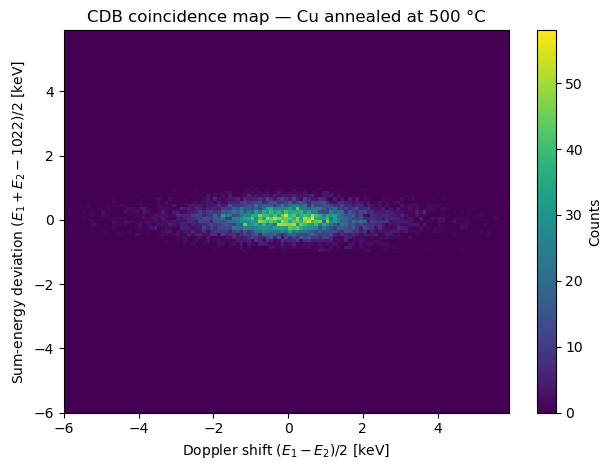

In [7]:
cdb.coincidence_map.plot(cbar_kwargs={'label': 'Counts'})
plt.xlabel('Doppler shift $(E_1 - E_2)/2$ [keV]')
plt.ylabel('Sum-energy deviation $(E_1 + E_2 - 1022)/2$ [keV]')
plt.title('CDB coincidence map — Cu annealed at 500 °C')
plt.tight_layout()
plt.show()

## 6. Project to 1D spectra

`doppler_broadening()` sums the coincidence map along the resolution axis, collapsing it to a function of `(E₁ − E₂)/2`. The result is a `PASdb` instance centred at 0 keV (the natural zero of the CDB Doppler axis), directly analogous to a single-detector DB spectrum but with far lower background.

`resolution()` sums along the Doppler axis, giving the sum-energy distribution. Its FWHM equals √2 × the single-detector FWHM and can be used to verify the detector calibration.

Note the momentum distribution broadening at high momenta in the Doppler spectrum — this wing structure encodes core-electron annihilation. The resolution spectrum background level indicates how well accidental coincidences have been suppressed.

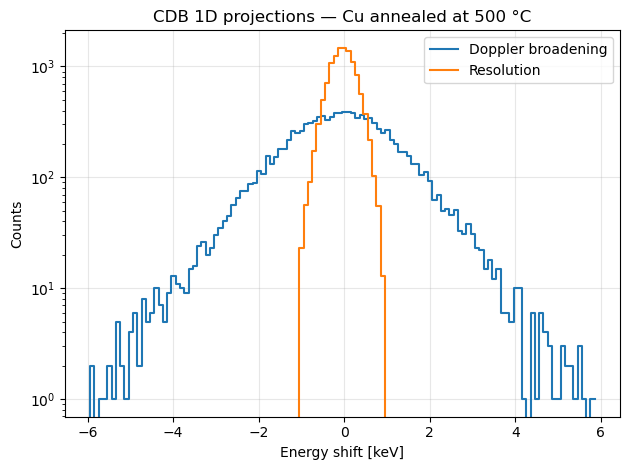

In [8]:
# center_value=0: CDB Doppler axis is naturally centred at 0 keV
db_cdb  = cdb.doppler_broadening(center_value=0)
res_cdb = cdb.resolution()

db_cdb.plot.step(yscale='log', label='Doppler broadening')
res_cdb.plot.step(yscale='log', label='Resolution')
plt.ylabel('Counts')
plt.xlabel('Energy shift [keV]')
plt.title('CDB 1D projections — Cu annealed at 500 °C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. S and W lineshape parameters

`db_cdb` is a `PASdb` instance, so S and W are calculated identically to single-detector DB. The window boundaries must be expressed **relative to 511 keV** (i.e., in the same centred frame as the CDB Doppler axis, where the peak is at 0 keV).

> **Adapt the window boundaries** to your detector resolution and sample system.

In [9]:
# ── Adapt window boundaries (relative to 511 keV) ────────────────────────────
total_energy_domain = np.array([507.7, 514.9]) - 511   # full integration range [keV]
energy_domain_s     = np.array([510.2, 511.8]) - 511   # S window — central region [keV]
energy_domain_w_l   = np.array([507.8, 509.3]) - 511   # W window — left wing [keV]
energy_domain_w_r   = np.array([512.7, 514.8]) - 511   # W window — right wing [keV]
# ─────────────────────────────────────────────────────────────────────────────

s = db_cdb.s_parameter_calculation(total_energy_domain, energy_domain_s)
w = db_cdb.w_parameter_calculation(total_energy_domain, energy_domain_w_l, energy_domain_w_r)

print(f"S = {s}")
print(f"W = {w}")

S = 0.492+/-0.005
W = 0.186+/-0.004


## 8. Resolution spectrum analysis

The resolution spectrum is a `Domain` and can be analysed with standard `pyspectrum` tools. The FWHM of this spectrum equals /√2  the single-detector FWHM — useful for verifying the combined detector resolution and checking the energy calibration alignment between detectors. A centre value close to 0 confirms that both detector axes are well-aligned after `centralize_peak=True`.

In [12]:
fwhm   = fwhm_estimator(res_cdb)
center = center_estimator(res_cdb)

print(f"Resolution FWHM:  {fwhm:.4f} keV")
print(f"Peak centre:      {center} keV")
print(f"Expected FWHM ≈ {(energy_resolution_det_1**2 + energy_resolution_det_2**2)**0.5/2:.2f} keV"
      f" = { (energy_resolution_det_1 + energy_resolution_det_2)/2/np.sqrt(2):.3f} keV")

Resolution FWHM:  0.7218 keV
Peak centre:      0.0340+/-0.0017 keV
Expected FWHM ≈ 0.75 keV = 0.753 keV
